# Maze Route as an Energy-Based Model

We model a maze as categorical variables and sample low-energy states. The goal is not to mark every open corridor as `Path`; it is to mark only the start-to-end route and leave dead ends as `NotPath`.

## Mathematical Model

Let the maze grid be a graph $G=(V,E)$ with one categorical random variable per grid cell,

$$
x_i \in \mathcal C = \{P,N,W\},
$$

where $P$ means `Path`, $N$ means `NotPath`, and $W$ means `Wall`. THRML samples from the Boltzmann distribution

$$
p_\beta(x) = \frac{\exp(-E_\beta(x))}{Z},
\qquad
E_\beta(x) = -\beta S(x),
$$

with score

$$
S(x) = \sum_{i\in V} b_i[x_i]
     + \sum_{(i,j)\in E} A[x_i,x_j]
     + \sum_{i\in V_\text{open}} D_i(x_i, x_{\mathcal N(i)}).
$$

In this notebook the pairwise matrix $A$ is set to zero; the route shape comes from node biases and the local degree factor $D_i$.

## Factors

The node bias $b_i$ pins known cell types:

$$
b_i =
\begin{cases}
[-8,-8,12] & \text{if cell } i \text{ is a maze wall},\\
[5,-8,-8] & \text{if } i \in \{\text{start},\text{end}\},\\
[0,0,-8] & \text{otherwise.}
\end{cases}
$$

For an open cell, define its Path degree

$$
d_i(x)=\sum_{j\in\mathcal N(i)} \mathbf 1[x_j=P].
$$

The degree-shell factor rewards path geometry:

$$
D_i =
\begin{cases}
r_P & x_i=P \text{ and } d_i=1, && i \in \{\text{start},\text{end}\},\\
r_P & x_i=P \text{ and } d_i=2, && \text{ordinary open cell},\\
r_N & x_i=N \text{ and } d_i\le 1, && \text{ordinary open cell},\\
-\lambda & \text{otherwise.}
\end{cases}
$$

We use $r_P=0.5$, $r_N=0.55$, $\lambda=8$, and $\beta=2$. The factor touches a center cell and its four neighbors, so the Gibbs schedule uses a 5-color `two_hop` block scheme: no two variables inside one degree shell are updated at the same time.

In [7]:
import jax
import matplotlib.pyplot as plt
import numpy as np
from thrml import SamplingSchedule

from utils import config, model, visualize
from utils.wrapper_maze import generate_maze, maze_to_graph

In [8]:
EBM_PARAMS = dict(
    bias_wall=np.array([-8.0, -8.0, 12.0]),
    bias_goal=np.array([5.0, -8.0, -8.0]),
    bias_other=np.array([0.0, 0.0, -8.0]),
    edge_weights=np.zeros_like(config.EDGE_WEIGHTS),
    block_scheme='two_hop',
)
DEGREE_PARAMS = dict(
    degree_path_reward=0.5,
    degree_off_reward=0.55,
    degree_penalty=8.0,
)
BETA = 2.0
SCHEDULE = SamplingSchedule(n_warmup=500, n_samples=config.N_SAMPLES, steps_per_sample=5)

In [9]:
def solve_with_ebm(width, height, seed, key_seed=None):
    grid, start, end = generate_maze(width=width, height=height, seed=seed)
    mg = maze_to_graph(grid, start, end, **EBM_PARAMS)
    program = model.build_program(mg, beta=BETA, **DEGREE_PARAMS)

    # Start from the over-complete state: every open cell is Path, every wall is Wall.
    # The degree factor then prunes branches into NotPath.
    init_state = np.where(grid.reshape(-1) == 1, config.WALL, config.PATH).astype(np.uint8)
    states = model.run_sampling(
        jax.random.key(seed if key_seed is None else key_seed),
        mg,
        program,
        SCHEDULE,
        init_state=init_state,
    )
    energies = model.energy_of_states(mg, states, beta=BETA, **DEGREE_PARAMS)
    best_idx = np.unravel_index(np.argmin(energies), energies.shape)
    best_state = states[best_idx]

    target = model.shortest_path_mask(mg).reshape(-1)
    exact_samples = ((states == config.PATH) == target).all(axis=2)
    path = best_state == config.PATH
    open_cells = grid.reshape(-1) == 0

    return dict(
        grid=grid,
        start=start,
        end=end,
        mg=mg,
        best_state=best_state,
        energy=float(energies[best_idx]),
        path_cells=int(path.sum()),
        shortest_cells=int(target.sum()),
        exact_best=bool((path == target).all()),
        exact_chains=int(exact_samples.any(axis=1).sum()),
        extra_path=int((path & open_cells & ~target).sum()),
        missing_path=int((target & ~path).sum()),
    )

## One Maze

grid: (17, 17) | start: (9, 0) | end: (7, 16)
lowest energy: -3999.6
best state equals shortest route: True
path cells: 23
extra Path cells: 0
missing route cells: 0
chains that sampled the exact route: 17/32


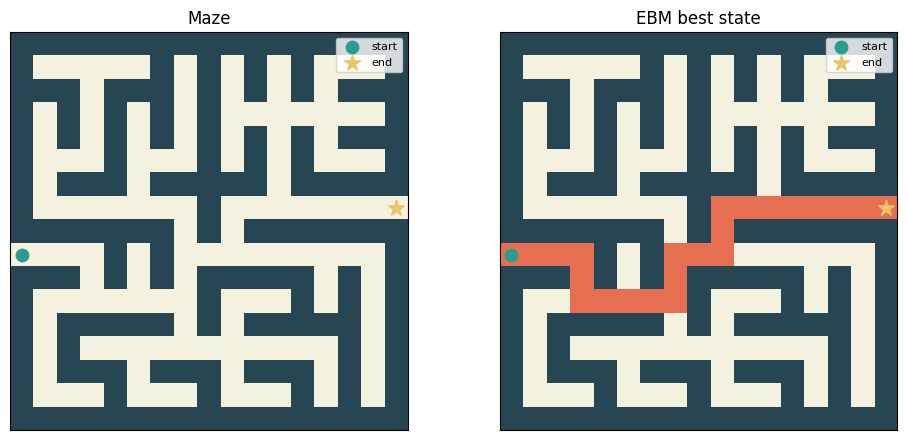

In [10]:
example = solve_with_ebm(width=8, height=8, seed=7)
print('grid:', example['grid'].shape, '| start:', example['start'], '| end:', example['end'])
print('lowest energy:', example['energy'])
print('best state equals shortest route:', example['exact_best'])
print('path cells:', example['path_cells'])
print('extra Path cells:', example['extra_path'])
print('missing route cells:', example['missing_path'])
print('chains that sampled the exact route:', f"{example['exact_chains']}/{config.N_CHAINS}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
visualize.plot_maze(example['grid'], example['start'], example['end'], ax=axes[0], title='Maze')
visualize.plot_state(example['mg'], example['best_state'], ax=axes[1], title='EBM best state')
fig.tight_layout();

## Different Seeds and Sizes

In [11]:
cases = [
    dict(width=4, height=4, seed=1),
    dict(width=5, height=5, seed=3),
    dict(width=8, height=8, seed=7),
    dict(width=10, height=10, seed=12),
]
examples = [solve_with_ebm(**case) for case in cases]

print(f"{'maze':>7} {'seed':>4} {'shortest':>8} {'path':>5} {'exact':>7} {'exact chains':>12} {'extra':>5} {'missing':>7}")
for case, result in zip(cases, examples):
    maze_name = f"{case['width']}x{case['height']}"
    print(f"{maze_name:>7} {case['seed']:>4} {result['shortest_cells']:>8} "
          f"{result['path_cells']:>5} {str(result['exact_best']):>7} "
          f"{result['exact_chains']:>5}/{config.N_CHAINS:<6} "
          f"{result['extra_path']:>5} {result['missing_path']:>7}")

   maze seed shortest  path   exact exact chains extra missing
    4x4    1       11    11    True    32/32         0       0
    5x5    3       25    25    True    28/32         0       0
    8x8    7       23    23    True    17/32         0       0
  10x10   12       39    39    True     9/32         0       0


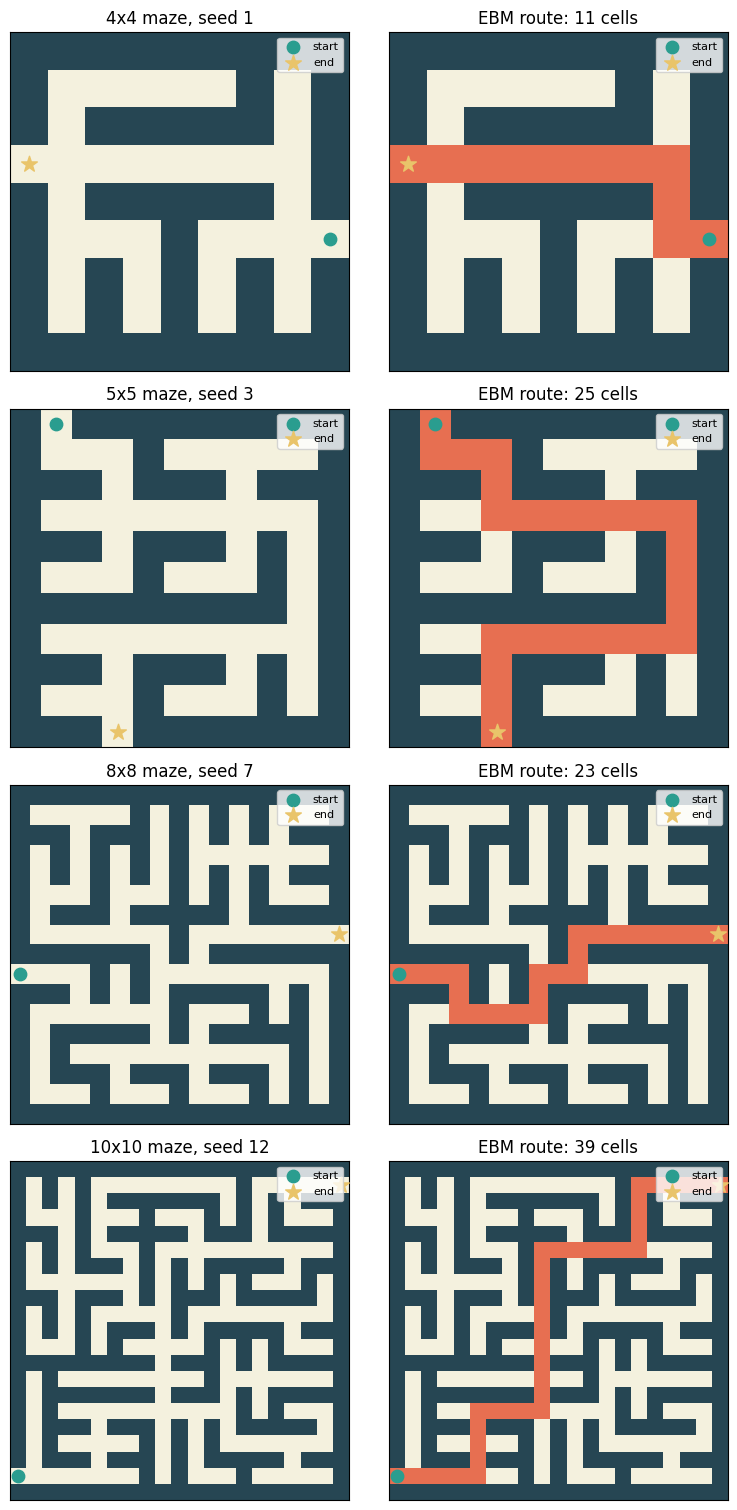

In [12]:
fig, axes = plt.subplots(len(examples), 2, figsize=(8, 3.8 * len(examples)))
for row, (case, result) in enumerate(zip(cases, examples)):
    visualize.plot_maze(
        result['grid'], result['start'], result['end'], ax=axes[row, 0],
        title=f"{case['width']}x{case['height']} maze, seed {case['seed']}"
    )
    visualize.plot_state(
        result['mg'], result['best_state'], ax=axes[row, 1],
        title=f"EBM route: {result['path_cells']} cells"
    )
fig.tight_layout();

## Notes

The sampler is stochastic, so not every chain has to land on the exact route. We select the lowest-energy sampled state. In these examples that state is the shortest start-to-end route and has no dead-end Path cells.